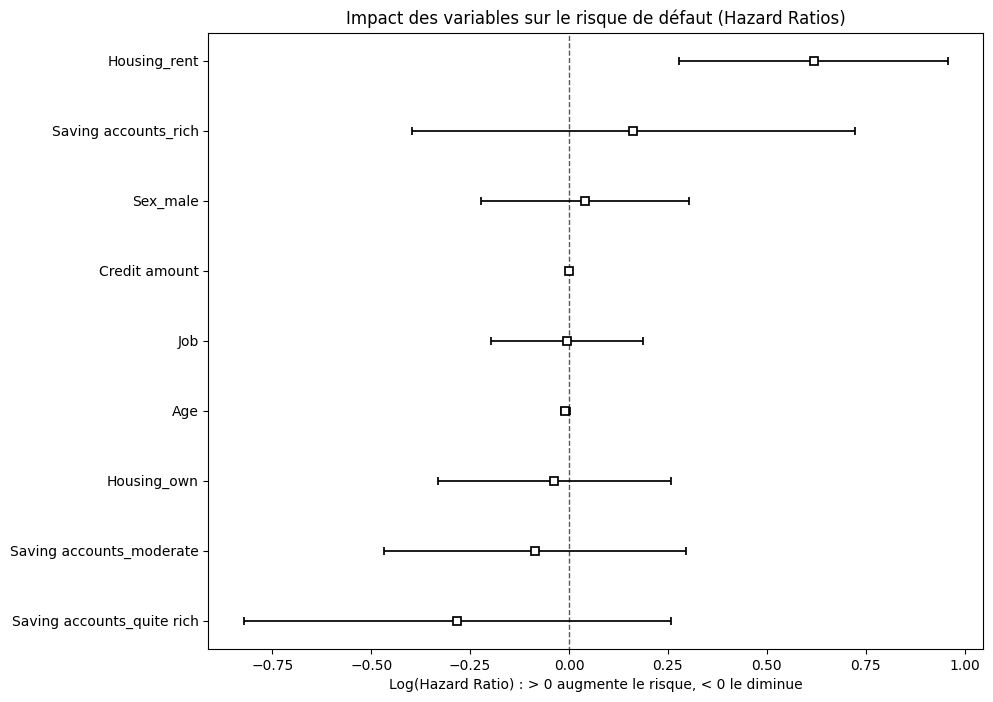

<lifelines.CoxPHFitter: fitted with 1000 total observations, 828 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 172
   partial log-likelihood = -1007.14
         time fit was run = 2026-09-26 23:42:41 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
Age                        -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
Credit amount              -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
Job                        -0.01      0.99      0.10           -0.20            0.19                0.82                1.20
Saving accounts_moderate   -0.09      0.92      0.19           -0.47            0.30                0.63                1.34
Saving accounts_quite rich -0.28      0.75      0.28           -0.82            0.26                0.44                1.29
Saving accounts_rich        0.16      1.18      0.29           -0.40            0.72                0.67                2.06
Housing_own                -0.04      0.96      0.15           -0.33            0.26                0.72                1.29
Housing_rent                0.62      1.86      0.17            0.28            0.96                1.32                2.61
Sex_male                    0.04      1.04      0.13           -0.22            0.30                0.80                1.36

                            cmp to     z      p  -log2(p)
covariate                                                
Age                           0.00 -1.73   0.08      3.57
Credit amount                 0.00 -6.24 <0.005     31.09
Job                           0.00 -0.06   0.95      0.07
Saving accounts_moderate      0.00 -0.44   0.66      0.60
Saving accounts_quite rich    0.00 -1.02   0.31      1.71
Saving accounts_rich          0.00  0.57   0.57      0.81
Housing_own                   0.00 -0.25   0.80      0.31
Housing_rent                  0.00  3.57 <0.005     11.45
Sex_male                      0.00  0.30   0.76      0.39
---
Concordance = 0.76
Partial AIC = 2032.27
log-likelihood ratio test = 69.31 on 9 df
-log2(p) of ll-ratio test = 35.48

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# 1. Chargement des données German Credit
csv_path = "german_credit_data.csv" if os.path.exists("german_credit_data.csv") else "../german_credit_data.csv"
data = pd.read_csv(csv_path, index_col=0)

# 2. Préparation des variables de survie (time & event)
data['time'] = data['Duration']

# Si la colonne 'event' n'existe pas encore dans le dataframe, on la génère
if 'event' not in data.columns:
    np.random.seed(42)
    prob_default = np.where(data['Housing'] == 'rent', 0.35, 0.15)
    data['event'] = np.random.binomial(1, prob_default)

# 3. Sélection des variables pour le modèle de Cox
colonnes_utiles = ['Age', 'Credit amount', 'Job', 'Saving accounts', 'Housing', 'Sex', 'time', 'event']
df_cox = data[colonnes_utiles].copy()

# 4. Encodage One-Hot pour les variables catégorielles (textes)
df_cox_encoded = pd.get_dummies(df_cox, drop_first=True)

# Conversion des colonnes booléennes en float pour lifelines
for col in df_cox_encoded.columns:
    if df_cox_encoded[col].dtype == bool:
        df_cox_encoded[col] = df_cox_encoded[col].astype(float)

# 5. Entraînement du modèle de Cox
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_encoded, duration_col='time', event_col='event')

# 6. Affichage graphique (Forest Plot - Hazard Ratios)
plt.figure(figsize=(10, 8))
cph.plot()
plt.title("Impact des variables sur le risque de défaut (Hazard Ratios)")
plt.xlabel("Log(Hazard Ratio) : > 0 augmente le risque, < 0 le diminue")
plt.show()

# 7. Affichage du résumé statistique complet
cph.print_summary()
